In [13]:
import time
import pandas as pd
import json
import numpy as np
from datetime import datetime
from datetime import timezone
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import ListedColormap
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import plotly.graph_objects as go
from plotly.subplots import make_subplots


import itertools
import random

# Load Datasets

In [14]:
def load_cycles_from_npz(filename):
    """
    Loads a flattened .npz file and reconstructs the nested dictionary.
    """
    data = np.load(filename)
    reconstructed = {}
    
    for key in data.files:
        # Split the key (e.g., 'rough_foot_force')
        # We use rsplit once from the right to handle sensor names with underscores
        parts = key.split('_', 2) 
        if len(parts) < 2: continue
        
        terrain, sensor = f"{parts[0]}_{parts[1]}", parts[2]
        
        if terrain not in reconstructed:
            reconstructed[terrain] = {}
        
        # Convert the (N, 100, F) array back into a list of (100, F) arrays
        # This makes it compatible with your existing segment_all_trials output
        reconstructed[terrain][sensor] = [cycle for cycle in data[key]]
        
    print(f"Loaded {len(reconstructed)} terrains from {filename}")
    return reconstructed

# --- Execution ---
dataset = load_cycles_from_npz('walking_terrain_datasets.npz')

Loaded 6 terrains from walking_terrain_datasets.npz


# Functions

In [15]:
def split_gait_dataset(dataset, train_ratio=0.8, seed=42):
	"""
	Splits the gait cycle dataset into training and testing sets.
	Safely handles sensors with mismatched cycle counts.
	"""
	random.seed(seed)
	train_set = {}
	test_set = {}

	for terrain in dataset.keys():
		# 1. FIND THE MINIMUM CYCLE COUNT ACROSS ALL SENSORS
		# This ensures we don't try to access an index that doesn't exist for a sensor
		sensor_counts = [len(dataset[terrain][s]) for s in dataset[terrain].keys()]
		if not sensor_counts:
			continue
			
		min_cycles = min(sensor_counts)
		
		# 2. Generate indices based on the shortest sensor stream
		indices = list(range(min_cycles))
		random.shuffle(indices)
		
		split_idx = int(min_cycles * train_ratio)
		train_indices = indices[:split_idx]
		test_indices = indices[split_idx:]
		
		train_set[terrain] = {}
		test_set[terrain] = {}

		# 3. Distribute cycles
		for sensor in dataset[terrain].keys():
			all_cycles = dataset[terrain][sensor]
			# We only take the cycles up to min_cycles to stay synchronized
			train_set[terrain][sensor] = [all_cycles[i] for i in train_indices]
			test_set[terrain][sensor] = [all_cycles[i] for i in test_indices]
			
		print(f"Terrain {terrain.upper()}: Used {min_cycles} synchronized cycles. "
			  f"({len(train_indices)} train, {len(test_indices)} test)")

	return train_set, test_set

def split_and_roll_gait_dataset(dataset, train_ratio=0.8, num_rolls=3, augment_test=True, seed=42):
    """
    Splits the dataset and safely applies 'rolling' augmentation to prevent data leakage.
    
    Args:
        dataset: The nested dictionary containing terrain -> sensor -> cycles.
        train_ratio: Percentage of data to use for training.
        num_rolls: How many additional phase-shifted cycles to generate per original cycle. 
                   (e.g., num_rolls=3 creates shifts at 25%, 50%, and 75% of the cycle length)
        augment_test: If True, applies rolling to the test set as well. Usually kept False.
    """
    random.seed(seed)
    train_set = {}
    test_set = {}

    for terrain in dataset.keys():
        # Initialize dictionaries for this terrain
        train_set[terrain] = {s: [] for s in dataset[terrain].keys()}
        test_set[terrain]  = {s: [] for s in dataset[terrain].keys()}
        
        # 1. FIND THE MINIMUM CYCLE COUNT (Synchronization Check)
        sensor_counts = [len(dataset[terrain][s]) for s in dataset[terrain].keys()]
        if not sensor_counts:
            continue
            
        min_cycles = min(sensor_counts)
        sensors = list(dataset[terrain].keys())
        
        # 2. SPLIT INDICES FIRST (To prevent data leakage)
        indices = list(range(min_cycles))
        random.shuffle(indices)
        
        split_idx = int(min_cycles * train_ratio)
        train_indices = indices[:split_idx]
        test_indices = indices[split_idx:]
        
        # 3. HELPER FUNCTION TO ROLL DATA
        def extract_and_roll(target_dict, index_list, apply_rolling):
            for i in index_list:
                # Find the length of this specific gait cycle (assuming all sensors share the same length for cycle 'i')
                cycle_len = len(dataset[terrain][sensors[0]][i])
                
                # Calculate the exact array indices to shift by.
                # If num_rolls=3, shifts = [0, 25%, 50%, 75% of cycle length]
                if apply_rolling:
                    shifts = [int(cycle_len * (j / (num_rolls + 1))) for j in range(num_rolls + 1)]
                else:
                    shifts = [0] # Only keep the original, unshifted cycle
                
                # Apply the shifts to every sensor so they stay perfectly synchronized
                for shift in shifts:
                    for sensor in sensors:
                        cycle_data = dataset[terrain][sensor][i]
                        
                        # Apply Left-Shift Phase Rolling
                        if isinstance(cycle_data, list):
                            rolled_cycle = cycle_data[shift:] + cycle_data[:shift]
                        else:
                            # Fallback just in case your data is stored as Numpy arrays
                            rolled_cycle = np.roll(cycle_data, -shift, axis=0) 
                            
                        target_dict[sensor].append(copy.deepcopy(rolled_cycle))

        # 4. EXTRACT AND AUGMENT
        # Augment the training set
        extract_and_roll(train_set[terrain], train_indices, apply_rolling=True)
        
        # Extract the testing set (Un-augmented by default)
        extract_and_roll(test_set[terrain], test_indices, apply_rolling=augment_test)

        # Print detailed diagnostic readout
        train_count = len(train_set[terrain][sensors[0]])
        test_count = len(test_set[terrain][sensors[0]])
        
        print(f"Terrain {terrain.upper()}:")
        print(f" -> Original unique cycles: {min_cycles}")
        print(f" -> TRAIN set grew to {train_count} cycles (Augmented {num_rolls}x)")
        print(f" -> TEST set contains {test_count} cycles (Original only)\n")

    return train_set, test_set

def simulate_dropped_packets_with_zeros(X_test, drop_rate=0.10, seed=42):
    """
    Simulates signal loss by randomly overwriting entire timesteps with zeros.
    Preserves the original sequence length and structural timeline.
    
    Parameters:
    - X_test: List of 2D numpy arrays (timesteps, features)
    - drop_rate: Float representing the percentage of packets to zero out (e.g., 0.10 for 10%)
    - seed: Random seed for reproducibility
    
    Returns:
    - X_dropped: List of zero-masked 2D numpy arrays with identical original shapes.
    """
    np.random.seed(seed)
    X_dropped = []
    
    for cycle in X_test:
        num_timesteps = cycle.shape[0]
        
        # Calculate how many packet steps to turn into zeros
        num_to_drop = int(num_timesteps * drop_rate)
        
        # Randomly select which time indices will lose their signal
        drop_indices = np.random.choice(num_timesteps, num_to_drop, replace=False)
        
        # Create a deep copy so we don't accidentally corrupt the pristine data in memory
        degraded_cycle = cycle.copy()
        
        # Patch those exact positions with zero across all sensor features
        degraded_cycle[drop_indices, :] = 0.0
        
        X_dropped.append(degraded_cycle)
        
    return X_dropped

def simulate_sensor_noise_ptp(X_test, noise_level=0.10, seed=42):
    """
    Simulates noise scaled to the Peak-to-Peak (Full-Scale) range of the sensor.
    	
    Yes, absolutely! In fact, scaling noise to the Peak-to-Peak (PTP) value or the Maximum Absolute Magnitude 
    is exactly how hardware engineers typically define the "Full-Scale Signal-to-Noise Ratio (SNR)"
    for physical sensors like load cells and ADCs.
    
    """
    np.random.seed(seed)
    X_noisy = []
    
    for cycle in X_test:
        noisy_cycle = cycle.copy()
        
        # Calculate Peak-to-Peak (Max - Min) across time for each feature
        # This is the "Full-Scale Range" of the sensor for this specific step
        
        feature_scales = np.ptp(noisy_cycle, axis=0)
        # feature_scales = np.max(np.abs(noisy_cycle), axis=0)
        
        # Fallback for completely flat signals to prevent zero-scaling
        feature_scales[feature_scales == 0] = 1.0
        
        standard_normal_noise = np.random.normal(loc=0.0, scale=1.0, size=noisy_cycle.shape)
        
        # Scale the noise by the Peak-to-Peak range
        scaled_noise = standard_normal_noise * (noise_level * feature_scales)
        
        noisy_cycle += scaled_noise
        X_noisy.append(noisy_cycle)
        
    return X_noisy

In [16]:
def flatten_datasets(dataset_dict, terrain_to_id_map, sensor_order):
	"""
	Converts the nested dictionary into flat X and y lists for the ESN.
	
	dataset_dict: The output from your split_dataset function.
	terrain_to_id_map: Dictionary mapping string terrain names to integers (e.g., {'concrete': 0, 'grass': 1}).
	sensor_order: A strict list of sensor dictionary keys to ensure columns are always in the same order.
	"""
	X_formatted = []
	y_formatted = []
	
	for terrain, sensors_data in dataset_dict.items():
		if terrain not in terrain_to_id_map:
			continue # Skip terrains we aren't training on
			
		label = terrain_to_id_map[terrain]
		
		# Get the number of cycles for this terrain (they are synchronized)
		n_cycles = len(sensors_data[sensor_order[0]])
		
		for i in range(n_cycles):
			# For cycle 'i', gather data from all 16 joints (K, D, tau)
			cycle_columns = []
			for sensor_name in sensor_order:
				# Ensure it's a numpy array
				sensor_array = np.array(sensors_data[sensor_name][i])
				
				# If the sensor data is 1D (e.g., shape (90,)), reshape to (90, 1) so it stacks horizontally
				if len(sensor_array.shape) == 1:
					sensor_array = sensor_array.reshape(-1, 1)
				# --- ADD THIS PRINT STATEMENT TO DEBUG ---
				# if i == 0:  # Only print for the very first cycle so it doesn't spam your terminal
				# 	print(f"Sensor '{sensor_name}' contributes {sensor_array.shape[1]} features.")
				# # ---------------------------------------
				cycle_columns.append(sensor_array)
			
			# Stack all sensors horizontally to create the (90 timesteps x 48 features) matrix
			full_gait_matrix = np.hstack(cycle_columns)
            
			
			X_formatted.append(full_gait_matrix)
			y_formatted.append(label)
			
	return X_formatted, np.array(y_formatted)

def robust_flatten_datasets(data, labels_dict, sensor_keys):
    """
    Safely extracts and merges multiple sensor features from the dataset.
    Handles both single strings and lists of strings.
    """
    X, y = [], []
    
    # Ensure sensor_keys is a list so we can iterate over it
    if isinstance(sensor_keys, str):
        sensor_keys = [sensor_keys]
        
    for terrain, label in labels_dict.items():
        if terrain not in data:
            print(f"Warning: Terrain '{terrain}' not found in data.")
            continue
            
        # Use the first sensor to determine the number of gait cycles
        first_sensor = sensor_keys[0]
        if first_sensor not in data[terrain]:
            print(f"Warning: Sensor '{first_sensor}' not found in terrain '{terrain}'.")
            continue
            
        num_cycles = len(data[terrain][first_sensor])
        
        for i in range(num_cycles):
            cycle_features = []
            for s in sensor_keys:
                # Extract the shape (time_steps, features) array for this specific sensor and cycle
                cycle_features.append(data[terrain][s][i])
            
            # Concatenate all sensor features for this cycle along the column (feature) axis
            merged_cycle = np.concatenate(cycle_features, axis=-1)
            X.append(merged_cycle)
            y.append(label)
            
    return X, y

# Load Models

In [17]:
from models.model_1_esn_rr.env_pred import ESN_RR_Classification
from models.model_2_haptr.env_pred import HAPTR_Classifier
from models.model_3_cnn_rnn.env_pred import CNN_RNN_Classifier
from models.model_4_tcn.env_pred import TCN_Classifier

TERRAIN_LABELS = {
    'solid_ground'      : 0,
    'soft_ground'       : 1,
    'slippery_ground'   : 2,
    'rough_ground'      : 3,
    'muddy_ground'      : 4,
    'water_surface'     : 5
}

model_list = ['config_1', 'config_2', 'config_3', 'config_4', 'config_5']

sensor_list = [
    ['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb'],
    ['leg_stiffness', 'leg_damping', 'leg_torque_feedforward'],
    ['joint_torque_fb'],
    ['joint_torque_fb', 'foot_force'],
    ['foot_force']
]
model_arch_list = ['esn', 'haptr', 'cnn_rnn', 'tcn']
model_arch_obj_list = {}
for model_arch in model_arch_list:
	if model_arch == 'esn':
		model_arch_obj_list[model_arch] = ESN_RR_Classification()
	if model_arch == 'haptr':
		model_arch_obj_list[model_arch] = HAPTR_Classifier()
	if model_arch == 'cnn_rnn':
		model_arch_obj_list[model_arch] = CNN_RNN_Classifier()
	if model_arch == 'tcn':
		model_arch_obj_list[model_arch] = TCN_Classifier()

In [18]:
print("Splitting dataset...")
train_data, test_data = split_gait_dataset(dataset, train_ratio=0.8, seed=42)

Splitting dataset...
Terrain SOLID_GROUND: Used 569 synchronized cycles. (455 train, 114 test)
Terrain SOFT_GROUND: Used 569 synchronized cycles. (455 train, 114 test)
Terrain SLIPPERY_GROUND: Used 569 synchronized cycles. (455 train, 114 test)
Terrain ROUGH_GROUND: Used 569 synchronized cycles. (455 train, 114 test)
Terrain MUDDY_GROUND: Used 569 synchronized cycles. (455 train, 114 test)
Terrain WATER_SURFACE: Used 569 synchronized cycles. (455 train, 114 test)


# Test Dropouts

In [24]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import warnings
from sklearn.exceptions import InconsistentVersionWarning

# Ignore the version mismatch warning
warnings.filterwarnings("ignore", category=InconsistentVersionWarning)
# ==========================================
# 1. SELF-HEALING TERRAIN LABELS
# ==========================================
# Look directly into your memory and map whatever keys exist!
train_keys = list(train_data.keys())
test_keys = list(test_data.keys())

print("=========================================")
print(f"🛠️ AUTO-MAPPING TERRAIN LABELS")
print(f"Train Keys Found: {train_keys}")
print(f"Test Keys Found: {test_keys}")
print("=========================================\n")

# Create a dictionary mapping the found keys to integers 0-5
DYNAMIC_TERRAIN_LABELS = {terrain: idx for idx, terrain in enumerate(train_keys)}

# Make sure you updated these to match the diagnostic output from earlier!
# sensor_key = ['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb'] 
sensor_key = ['leg_stiffness', 'leg_damping', 'leg_torque_feedforward', 'foot_force', 'joint_angle_fb', 'joint_velocity_fb']


# ==========================================
# MAIN DROPOUT EVALUATION LOOP
# ==========================================
accuracy_dict = {}

for model_arch in model_arch_list:
    for drop_rate in np.arange(0.0, 0.5, 0.05):
        print(f"\n--- Model: {model_arch.upper()} | Drop Rate: {drop_rate*100:.0f}% ---")
        
        # Load the data using the DYNAMIC labels
        X_train, y_train = flatten_datasets(train_data, DYNAMIC_TERRAIN_LABELS, sensor_key)
        X_test, y_test = flatten_datasets(test_data, DYNAMIC_TERRAIN_LABELS, sensor_key)

        # EMERGENCY CHECK FOR BOTH TRAIN AND TEST
        if len(X_train) == 0:
            print(f"🛑 FATAL ERROR: X_train is completely empty!")
            print(f"   Check if {sensor_key} exists inside train_data.")
            break 
            
        if len(X_test) == 0:
            print(f"🛑 FATAL ERROR: X_test is completely empty!")
            break

        # 1. Drop signals FIRST (Simulating hardware packet loss)
        X_test_dropped = simulate_dropped_packets_with_zeros(X_test, drop_rate=drop_rate, seed=100)

        # 2. Conditional Scaling
        if model_arch in ['cnn_rnn', 'tcn']:
            X_train_np = np.array(X_train)
            X_test_np = np.array(X_test_dropped) 
            test_shape = X_test_np.shape
            
            # This is where it crashed last time!
            X_train_2d = X_train_np.reshape(-1, X_train_np.shape[-1])
            X_test_2d = X_test_np.reshape(-1, test_shape[-1])
            
            scaler = StandardScaler()
            scaler.fit(X_train_2d)
            eval_X = scaler.transform(X_test_2d).reshape(test_shape)
        else:
            eval_X = np.array(X_test_dropped)

        print("Booting up Controller...")
        
		# Load the correct model file type
		# 3. Load model_1 once
        if model_arch in ['esn']:
          model_arch_obj_list[model_arch].load_model(f"trained_models_w_noise/model_1_{model_arch}_config_8_w_cma_es.pt")
        else:
          model_arch_obj_list[model_arch].load_model(f"trained_models_w_noise/model_1_{model_arch}_config_8.pt")

        print("Evaluating on unseen Test Set...")
        y_pred = []

        # Predict
        for i in range(len(eval_X)):
            input_sample = eval_X[i] 
            
            predicted_class, _ = model_arch_obj_list[model_arch].predict(input_sample)
            y_pred.append(predicted_class)

        # Convert to numpy array for fast comparison
        y_pred = np.array(y_pred)
        y_test = np.array(y_test) 

        # Calculate Accuracy
        correct = np.sum(y_pred == y_test)
        accuracy = (correct / len(eval_X)) * 100
        print(f"-> Test Accuracy: {accuracy:.2f}%")

        model_arch_name = model_arch.upper() if model_arch != 'cnn_rnn' else 'CNN-RNN'

        if model_arch_name not in accuracy_dict:
            accuracy_dict[model_arch_name] = {}

        # Save the result
        accuracy_dict[model_arch_name][f"{drop_rate*100:.0f}%"] = accuracy

🛠️ AUTO-MAPPING TERRAIN LABELS
Train Keys Found: ['solid_ground', 'soft_ground', 'slippery_ground', 'rough_ground', 'muddy_ground', 'water_surface']
Test Keys Found: ['solid_ground', 'soft_ground', 'slippery_ground', 'rough_ground', 'muddy_ground', 'water_surface']


--- Model: ESN | Drop Rate: 0% ---
Booting up Controller...

[SUCCESS] ESN Model loaded from: 'trained_models_w_noise/model_1_esn_config_8_w_cma_es.pt'
--------------------------------------------------
💡 Hyperparameters:
   • Reservoir Size (n_res): 4117 neurons
   • Leak Rate:              0.5950285077844983
   • Target Classes:         6
   • Ignore Time Column:     True
   • Pooling Strategy:       'mean'

⚙️ Matrix Shapes:
   • W_in  (Input -> Res):   (4117, 53)
   • W_res (Res Dynamics):   (4117, 4117)
   • W_out (Res -> Output):  (6, 4117)

🛠️ System Config:
   • Scaler Initialized:     True
   • Expected Features:      53
   • Target Device:          CUDA
--------------------------------------------------

Evaluati


Generating Temporal Robustness Chart...

Final Accuracy Comparison: {'ESN': {'0%': 95.17543859649122, '5%': 94.2982456140351, '10%': 92.39766081871345, '15%': 85.96491228070175, '20%': 77.77777777777779, '25%': 66.22807017543859, '30%': 54.09356725146199, '35%': 45.614035087719294, '40%': 42.69005847953216, '45%': 36.25730994152047}, 'HAPTR': {'0%': 97.6608187134503, '5%': 96.9298245614035, '10%': 92.39766081871345, '15%': 84.94152046783626, '20%': 69.2982456140351, '25%': 58.62573099415205, '30%': 50.0, '35%': 43.71345029239766, '40%': 38.15789473684211, '45%': 34.7953216374269}, 'CNN-RNN': {'0%': 98.39181286549707, '5%': 98.09941520467837, '10%': 96.78362573099415, '15%': 94.44444444444444, '20%': 90.49707602339181, '25%': 84.7953216374269, '30%': 76.31578947368422, '35%': 64.32748538011695, '40%': 54.97076023391813, '45%': 45.90643274853801}, 'TCN': {'0%': 98.09941520467837, '5%': 97.953216374269, '10%': 97.80701754385966, '15%': 97.80701754385966, '20%': 96.78362573099415, '25%': 

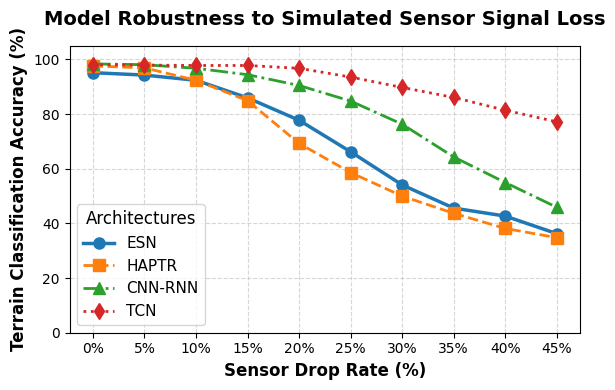

[SUCCESS] Robustness plot saved as 'dropped_packet_robustness.png'


In [25]:
import matplotlib.pyplot as plt

# --- 7. Plotting the Degradation Curve ---
print("\nGenerating Temporal Robustness Chart...")

plt.figure(figsize=(6, 4))

# Define clean styles to match top-tier academic journals (ICRA/IROS)
styles = {
    'ESN': {'color': '#1f77b4', 'marker': 'o', 'linewidth': 2.5, 'linestyle': '-'},
    'HAPTR': {'color': '#ff7f0e', 'marker': 's', 'linewidth': 2, 'linestyle': '--'},
    'CNN-RNN': {'color': '#2ca02c', 'marker': '^', 'linewidth': 2, 'linestyle': '-.'},
    'TCN': {'color': '#d62728', 'marker': 'd', 'linewidth': 2, 'linestyle': ':'},
    'STRN': {'color': '#9467bd', 'marker': 'v', 'linewidth': 2, 'linestyle': '--'}
}

print("\nFinal Accuracy Comparison:", accuracy_dict)

# Extract the drop rates from the inner dictionary keys dynamically
# e.g., ['5% Drop Rate', '10% Drop Rate', '20% Drop Rate', '50% Drop Rate']
drop_labels = list(next(iter(accuracy_dict.values())).keys())

for model_name, drops in accuracy_dict.items():
    # Fetch accuracies in order matching the drop labels
    accuracies = [drops[label] for label in drop_labels]
    
    # Get the designated visual style if defined, otherwise fallback to defaults
    style = styles.get(model_name, {'color': None, 'marker': 'o', 'linewidth': 2, 'linestyle': '-'})
    
    plt.plot(drop_labels, accuracies, label=model_name,
             color=style['color'],
             marker=style['marker'],
             linewidth=style['linewidth'],
             linestyle=style['linestyle'],
             markersize=8)

# Aesthetics and annotations
plt.title('Model Robustness to Simulated Sensor Signal Loss', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sensor Drop Rate (%)', fontsize=12, fontweight='bold')
plt.ylabel('Terrain Classification Accuracy (%)', fontsize=12, fontweight='bold')
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Architectures', fontsize=11, title_fontsize=12, loc='lower left')

# Shading the region where the continuous state integration dominates
# Only draw the shaded zone if we have at least 2 drop rate labels to span across
# if len(drop_labels) >= 2:
#     plt.axvspan(drop_labels[1], drop_labels[-1], color='gray', alpha=0.1, label='ESN Dominance Zone')
# else:
#     print("\n[NOTE] Not enough drop rates to draw the 'ESN Dominance Zone' shading.")

plt.tight_layout()

plt.tight_layout()

# Save image file directly
# plt.savefig('dropped_packet_robustness.png', dpi=300)
plt.show()

print("[SUCCESS] Robustness plot saved as 'dropped_packet_robustness.png'")

# Test Noise

In [31]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.exceptions import InconsistentVersionWarning

# Ignore the version mismatch warning
warnings.filterwarnings("ignore", category=InconsistentVersionWarning)
# Define parameters
noise_levels = np.arange(0.0, 0.55, 0.05)
seeds = [42, 100, 2023, 777, 999]
noise_stats = {}

# 1. PRE-LOAD DATA ONCE (Do this outside all loops)
sensor_key = ['leg_stiffness', 'leg_damping', 'leg_torque_feedforward', 'foot_force', 'joint_angle_fb', 'joint_velocity_fb']
X_train, y_train = flatten_datasets(train_data, TERRAIN_LABELS, sensor_key)
X_test_orig, y_test = flatten_datasets(test_data, TERRAIN_LABELS, sensor_key)

# 2. PRE-FIT SCALER ONCE (Fit on clean training data)
scaler = StandardScaler()
X_train_2d = np.vstack(X_train).reshape(-1, X_train[0].shape[-1])
scaler.fit(X_train_2d)

for model_arch in model_arch_list:
    model_arch_name = model_arch.upper() if model_arch != 'cnn_rnn' else 'CNN-RNN'
    noise_stats[model_arch_name] = {}
    
    print(f"\n--- Testing {model_arch_name} ---")
    
    # Load model once
    # 3. Load model_1 once
    if model_arch in ['esn']:
        model_arch_obj_list[model_arch].load_model(f"trained_models_w_noise/model_1_{model_arch}_config_8_w_cma_es.pt")
    else:
        model_arch_obj_list[model_arch].load_model(f"trained_models_w_noise/model_1_{model_arch}_config_8.pt")

    for level in noise_levels:
        level_str = f"{level*100:.0f}% Noise"
        seed_accuracies = []
        
        for seed in seeds:
            # A. APPLY SENSOR NOISE SIMULATION
            X_test_noisy = simulate_sensor_noise_ptp(X_test_orig, noise_level=level, seed=seed)

            # B. CONDITIONAL SCALING
            if model_arch in ['cnn_rnn', 'tcn']:
               # FIX: Convert list to NumPy array first
               X_test_np = np.array(X_test_noisy) 
               
               # Now we can safely get the shape
               test_shape = X_test_np.shape 
               
               # Reshape and scale
               X_test_2d = X_test_np.reshape(-1, test_shape[-1])
               eval_X = scaler.transform(X_test_2d).reshape(test_shape)
            else:
               # Also convert to array for the else case to ensure consistency
               eval_X = np.array(X_test_noisy)
                
            # C. PREDICT
            y_pred = []
            for i in range(len(eval_X)):
                predicted_class, _ = model_arch_obj_list[model_arch].predict(eval_X[i])
                y_pred.append(predicted_class)

            # D. CALCULATE ACCURACY
            correct = np.sum(np.array(y_pred) == np.array(y_test))
            seed_accuracies.append((correct / len(eval_X)) * 100)
            
        noise_stats[model_arch_name][level_str] = {
            'mean': np.mean(seed_accuracies),
            'std': np.std(seed_accuracies)
        }
        print(f"  {level_str} -> Mean Accuracy: {np.mean(seed_accuracies):.2f}%")


--- Testing ESN ---

[SUCCESS] ESN Model loaded from: 'trained_models_w_noise/model_1_esn_config_8_w_cma_es.pt'
--------------------------------------------------
💡 Hyperparameters:
   • Reservoir Size (n_res): 4117 neurons
   • Leak Rate:              0.5950285077844983
   • Target Classes:         6
   • Ignore Time Column:     True
   • Pooling Strategy:       'mean'

⚙️ Matrix Shapes:
   • W_in  (Input -> Res):   (4117, 53)
   • W_res (Res Dynamics):   (4117, 4117)
   • W_out (Res -> Output):  (6, 4117)

🛠️ System Config:
   • Scaler Initialized:     True
   • Expected Features:      53
   • Target Device:          CUDA
--------------------------------------------------

  0% Noise -> Mean Accuracy: 95.18%
  5% Noise -> Mean Accuracy: 95.23%
  10% Noise -> Mean Accuracy: 95.06%
  15% Noise -> Mean Accuracy: 94.62%
  20% Noise -> Mean Accuracy: 93.92%
  25% Noise -> Mean Accuracy: 91.73%
  30% Noise -> Mean Accuracy: 88.19%
  35% Noise -> Mean Accuracy: 83.36%
  40% Noise -> Mean A

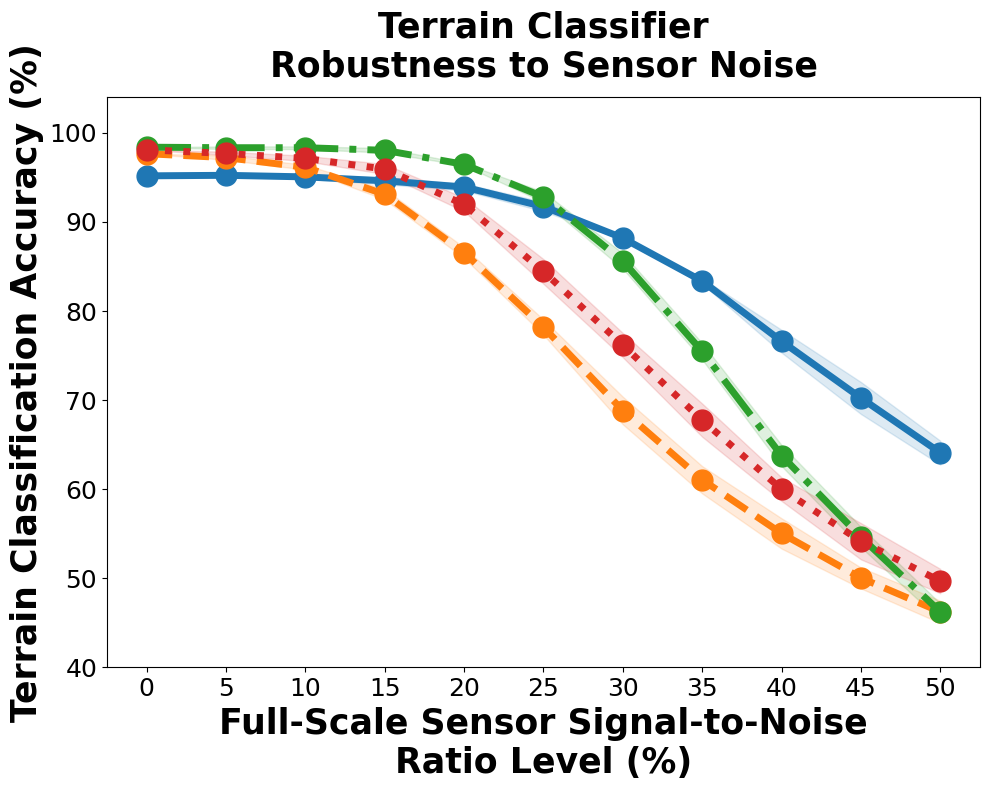

In [57]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Clean journal-ready styles
styles = {
    'ESN': {'color': '#1f77b4', 'marker': 'o', 'linestyle': '-'},
    'HAPTR': {'color': '#ff7f0e', 'marker': 'o', 'linestyle': '--'},
    'CNN-RNN': {'color': '#2ca02c', 'marker': 'o', 'linestyle': '-.'},
    'TCN': {'color': '#d62728', 'marker': 'o', 'linestyle': ':'},
    'STRN': {'color': '#9467bd', 'marker': 'o', 'linestyle': '--'}
}

# Generate noise levels matching your evaluation loop (0.0 to 0.9)
noise_levels = np.arange(0.0, 0.55, 0.05)

# Match the exact string keys inside your noise_stats dictionary
data_keys = [f"{nl*100:.0f}% Noise" for nl in noise_levels]

# Clean percentage strings to display on the X-axis ticks
display_labels = [f"{nl*100:.0f}" for nl in noise_levels]

for model_name, noise_data in noise_stats.items():
    # Safely extract means and stds sequentially using the exact dictionary keys
    means = np.array([noise_data[key]['mean'] for key in data_keys])
    stds = np.array([noise_data[key]['std'] for key in data_keys])
    
    style = styles.get(model_name, {'color': None, 'marker': 'o', 'linestyle': '-'})
    
    # 1. Plot the mean line against the display labels
    plt.plot(display_labels, means, label=model_name,
             color=style['color'], marker=style['marker'], 
             linestyle=style['linestyle'], linewidth=5, markersize=15)
    
    # 2. Plot the shaded standard deviation area (1 Std Dev above and below the mean)
    plt.fill_between(display_labels, means - stds, means + stds, 
                     color=style['color'], alpha=0.15)

plt.title('Terrain Classifier\nRobustness to Sensor Noise', fontsize=25, fontweight='bold', pad=15)  # \n(Statistical Validation Across Random Seeds)
plt.xlabel('Full-Scale Sensor Signal-to-Noise\nRatio Level (%)', fontsize=25, fontweight='bold')
plt.ylabel('Terrain Classification Accuracy (%)', fontsize=25, fontweight='bold')
plt.ylim(40, 104)
# plt.grid(True, linestyle='--', alpha=0.4)
# plt.legend(title='Architectures', fontsize=10, title_fontsize=11, loc='upper right')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.tight_layout()
plt.savefig('sensor_noise_robustness.png', dpi=300)
plt.show()

# Combine plots

NameError: name 'drop_rates' is not defined

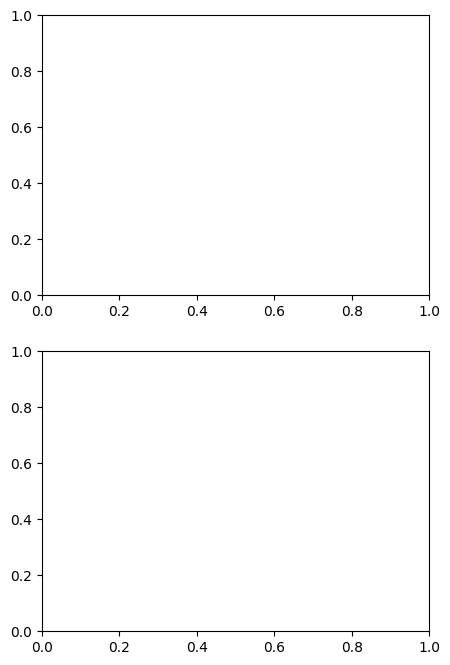

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a figure with 2 rows and 1 column
fig, axes = plt.subplots(2, 1, figsize=(5, 8))

# Clean journal-ready styles
styles = {
    'ESN': {'color': '#1f77b4', 'marker': 'o', 'linestyle': '-'},
    'HAPTR': {'color': '#ff7f0e', 'marker': 's', 'linestyle': '--'},
    'CNN-RNN': {'color': '#2ca02c', 'marker': '^', 'linestyle': '-.'},
    'TCN': {'color': '#d62728', 'marker': 'd', 'linestyle': ':'},
    'STRN': {'color': '#9467bd', 'marker': 'v', 'linestyle': '--'}
}


# ==========================================
# Subplot 1 (Top): Signal Losses
# ==========================================
ax1 = axes[0]
drop_labels = [f"{dr*100:.0f}%" for dr in drop_rates]

for model_name, drop_data in accuracy_stats.items():
    means = np.array([drop_data[label]['mean'] for label in drop_labels])
    stds = np.array([drop_data[label]['std'] for label in drop_labels])
    
    style = styles.get(model_name, {'color': None, 'marker': 'o', 'linestyle': '-'})
    
    ax1.plot(drop_labels, means, label=model_name,
             color=style['color'], marker=style['marker'], 
             linestyle=style['linestyle'], linewidth=2, markersize=6)
    
    ax1.fill_between(drop_labels, means - stds, means + stds, 
                     color=style['color'], alpha=0.15)

# NEW: Add grey horizontal span for 0-30% accuracy
ax1.axhspan(0, 30, facecolor='gray', alpha=0.2, zorder=0)

ax1.set_title('Robustness to Signal Losses', fontsize=13, pad=15)
ax1.set_xlabel('Sensor Signal Drop Rate (%)', fontsize=11)
ax1.set_ylabel('Terrain Classification Accuracy (%)', fontsize=11)
ax1.set_ylim(0, 105)


# ==========================================
# Subplot 2 (Bottom): Sensor Noise
# ==========================================
ax2 = axes[1]
noise_levels = np.arange(0.0, 1.00, 0.10)
data_keys = [f"{nl*100:.0f}% Noise" for nl in noise_levels]
display_labels = [f"{nl*100:.0f}%" for nl in noise_levels]

for model_name, noise_data in noise_stats.items():
    means = np.array([noise_data[key]['mean'] for key in data_keys])
    stds = np.array([noise_data[key]['std'] for key in data_keys])
    
    style = styles.get(model_name, {'color': None, 'marker': 'o', 'linestyle': '-'})
    
    ax2.plot(display_labels, means, label=model_name,
             color=style['color'], marker=style['marker'], 
             linestyle=style['linestyle'], linewidth=2, markersize=6)
    
    ax2.fill_between(display_labels, means - stds, means + stds, 
                     color=style['color'], alpha=0.15)

# NEW: Add grey horizontal span for 0-30% accuracy
# ax2.axhspan(0, 30, facecolor='gray', alpha=0.2, zorder=0)

ax2.set_title('Robustness to Sensor Noise', fontsize=13, pad=15)
ax2.set_xlabel('Full-Scale Sensor SNR Level (%)', fontsize=11)
ax2.set_ylabel('Terrain Classification Accuracy (%)', fontsize=11)
ax2.set_ylim(0, 105) 
ax2.legend(title='Architectures', fontsize=11, title_fontsize=12, loc='lower center', ncol=4, bbox_to_anchor=(0.45, -0.45))


# ==========================================
# Final Figure Adjustments
# ==========================================
plt.tight_layout()

# Save and show
plt.savefig('combined_robustness.png', dpi=500)
plt.show()